# Portfolio Benchmark

This notebook is the compact validation page for the mean-variance portfolio benchmark.

## Environment Basics

- State space: $W_t\in\mathbb{R}$, the representative wealth.
- Action space: $\alpha_t\in\mathbb{R}$, the risky allocation/control.
- Population law: summarized by the mean wealth $m_t=\mathbb{E}[W_t]$.
- Policy class: 

$$
\alpha_t\sim\mathcal{N}\big(k_t(W_t-m_t)+\ell_t,\tau_t^2\big).
$$

- Goal: maximize terminal mean-variance utility

$$
J(\theta)=\mathbb{E}[W_T]-\chi\operatorname{Var}(W_T).
$$

- Reference: closed-form mean-variance optimizer and exact objective/gradient diagnostics.


In [1]:
import sys
from pathlib import Path

import pandas as pd

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from mfc.experiments import notebook_helpers as nh

ENV_NAME = "portfolio"
BASE_DIR = ROOT / "runs" / "extended_benchmark_bundles" / ENV_NAME
PRESET = "mid"
QUICK = PRESET == "smoke"
RUN_MISSING = False
FORCE_REBUILD = False
EXTENDED = True


In [2]:
bundle = (
    nh.ensure_continuous_benchmark_bundle(
        ENV_NAME,
        BASE_DIR,
        quick=QUICK,
        force=FORCE_REBUILD,
        extended=EXTENDED,
        preset=PRESET,
    )
    if RUN_MISSING
    else nh.continuous_bundle_paths(ENV_NAME, BASE_DIR)
)

histories = nh.load_training_histories(bundle)
application = nh.load_application_data(bundle)
studies = nh.load_study_data(bundle)
grid_metrics = nh.load_study_grid_metrics(bundle)
diagnostics = nh.load_diagnostic_data(bundle)
optimization_history = nh.load_optimization_history(bundle)

bundle


{'env': 'portfolio',
 'base_dir': PosixPath('/home/adonis/Internship/MFC_RL/runs/extended_benchmark_bundles/portfolio'),
 'train': {'continuous-mfreinforce': PosixPath('/home/adonis/Internship/MFC_RL/runs/extended_benchmark_bundles/portfolio/train/portfolio_continuous-mfreinforce'),
  'reinforce': PosixPath('/home/adonis/Internship/MFC_RL/runs/extended_benchmark_bundles/portfolio/train/portfolio_reinforce'),
  'exact-gradient': PosixPath('/home/adonis/Internship/MFC_RL/runs/extended_benchmark_bundles/portfolio/train/portfolio_exact-gradient')},
 'application': {'continuous-mfreinforce': PosixPath('/home/adonis/Internship/MFC_RL/runs/extended_benchmark_bundles/portfolio/application/portfolio_continuous-mfreinforce'),
  'reinforce': PosixPath('/home/adonis/Internship/MFC_RL/runs/extended_benchmark_bundles/portfolio/application/portfolio_reinforce'),
  'exact-gradient': PosixPath('/home/adonis/Internship/MFC_RL/runs/extended_benchmark_bundles/portfolio/application/portfolio_exact-gradient

## Main Results

These are the core portfolio checks.

1. **Validation objective over training**: $J(\theta_k)$, with the closed-form optimizer as a dashed reference.
2. **Perturbed objective comparison**: $J^\lambda(\hat\theta)$ for several perturbation scales.
3. **Policy coefficients**: learned $k_t$ and $\ell_t$ against the closed-form optimizer.
4. **Wealth behavior**: mean/variance trajectories and the terminal mean-variance frontier.


,algorithm,learned_objective_J,closed_form_objective_J_star,objective_gap,terminal_mean,terminal_variance,downside_probability
0,continuous MF-REINFORCE,0.603863,0.80247,0.198608,0.976727,0.037044,0.0
1,classical REINFORCE,0.603290,0.80247,0.199181,0.972851,0.037752,0.0
2,exact gradient,0.722039,0.80247,0.080432,1.013073,0.031928,0.0


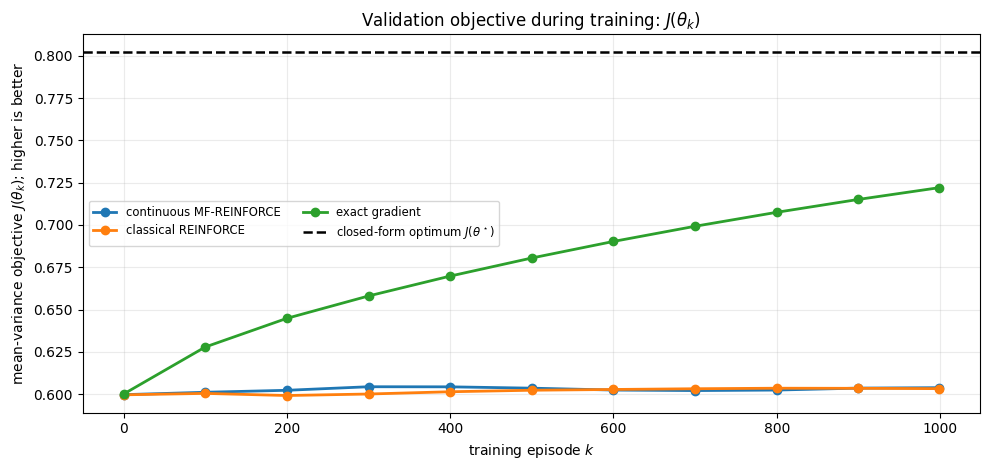

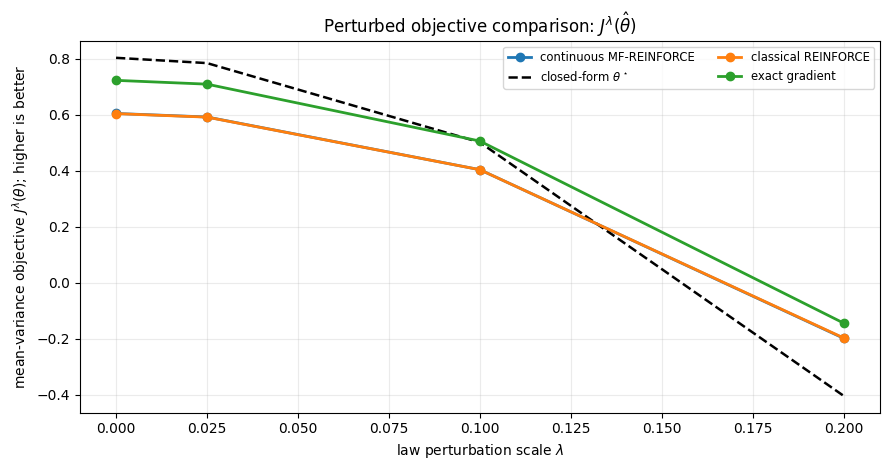

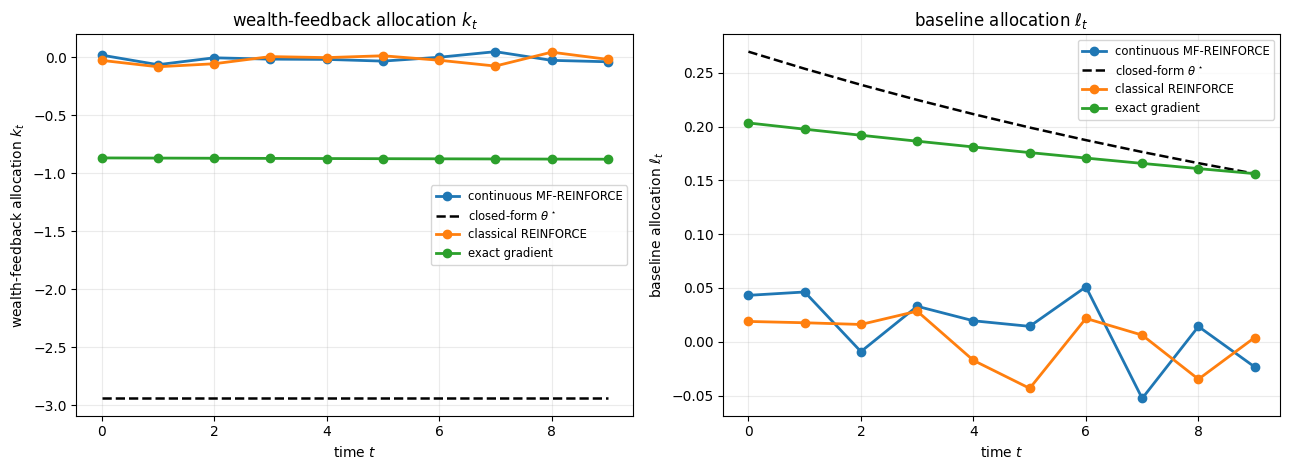

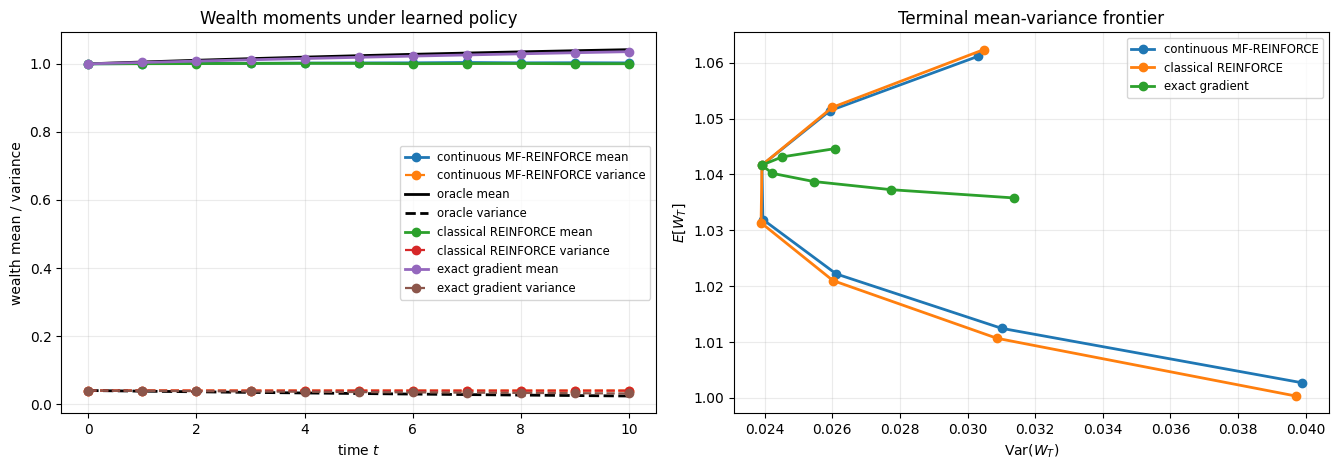

In [3]:
display(nh.portfolio_main_summary_table(application))
nh.plot_portfolio_main_results(bundle, histories, application, studies)


## Estimator Diagnostic Appendix

The appendix tracks whether the continuous MF-REINFORCE estimator is behaving sensibly:

$$
\mathbb{E}[d(M^\lambda,\mu)],
\qquad
\operatorname{MSE}(\widehat g),
\qquad
\operatorname{tr}\operatorname{Cov}(S_\lambda),
\qquad
\mathbb{E}\|\widehat D_t-D_t\|_2^2.
$$

The oracle gradient is the exact mean-variance gradient when available.


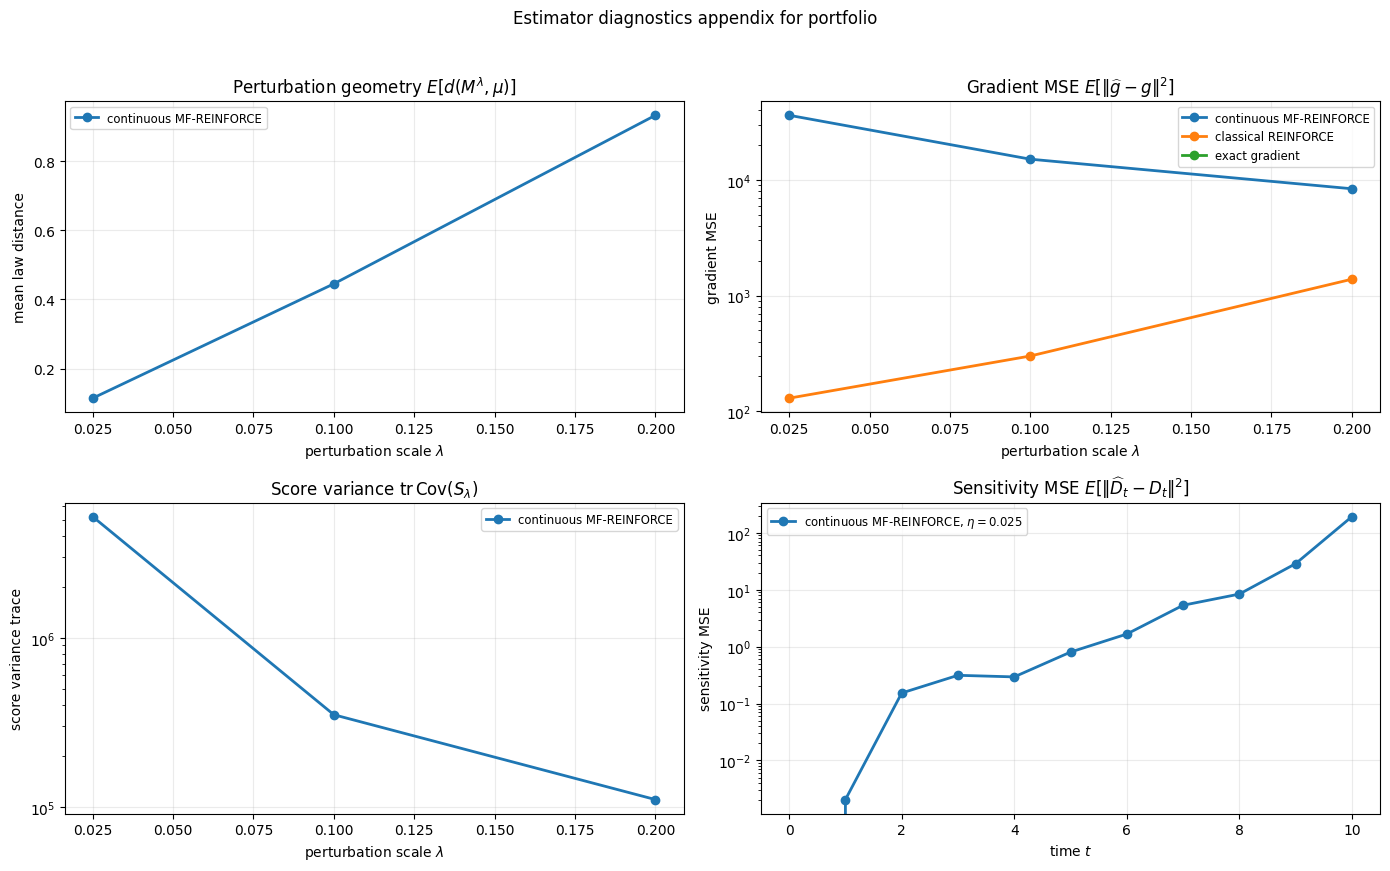

In [4]:
nh.plot_continuous_diagnostic_appendix(ENV_NAME, diagnostics)


## Optional Extended Studies

Run this section for budget, horizon, robustness, adaptive lambda, particle approximation, and ablation checks.


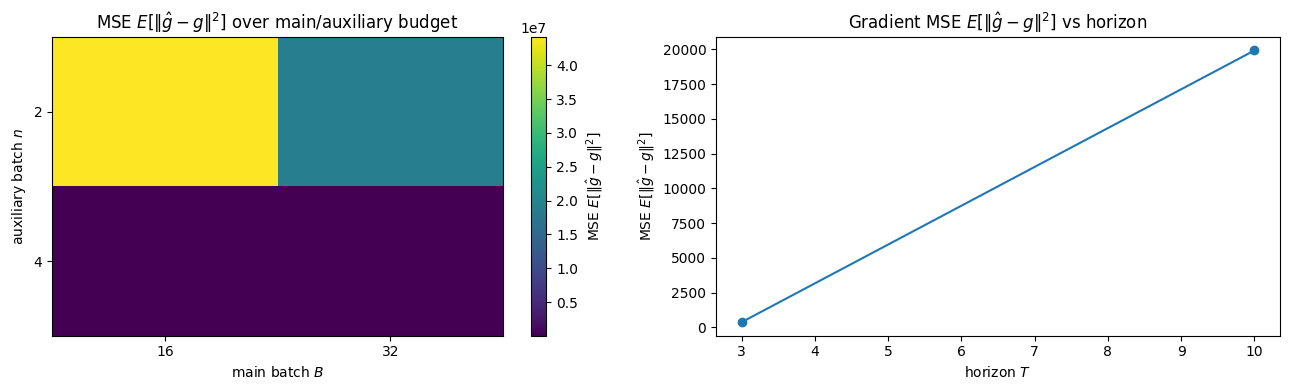

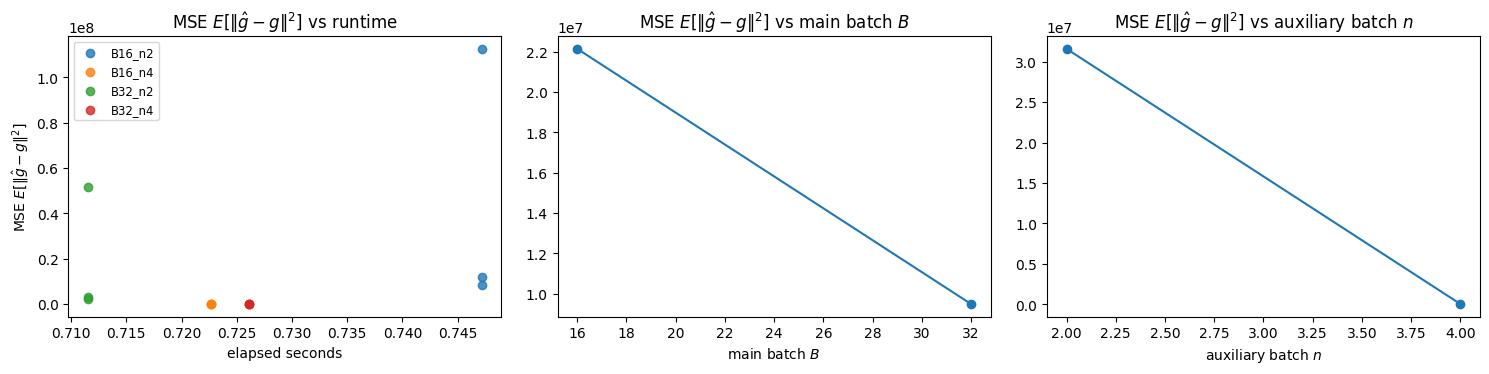

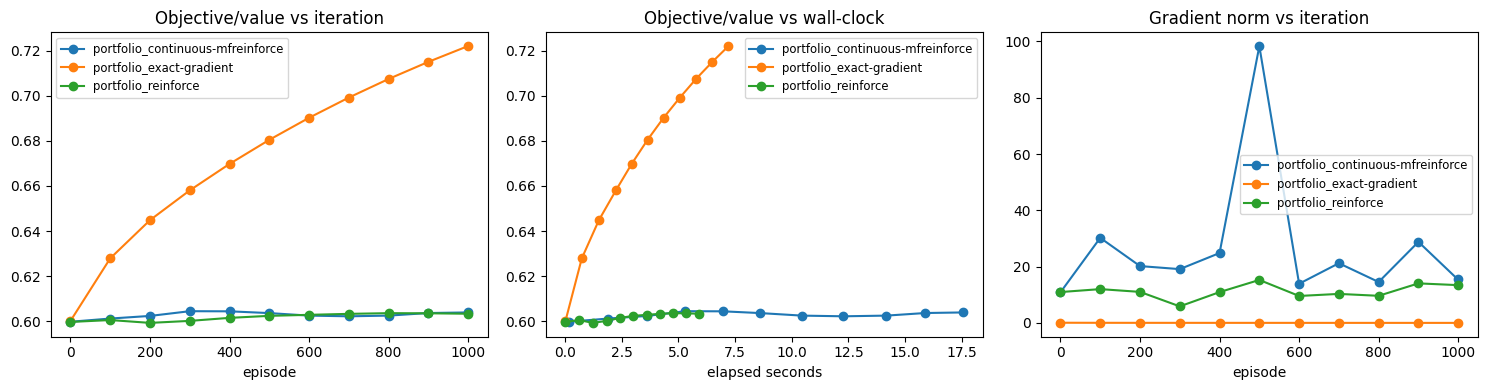

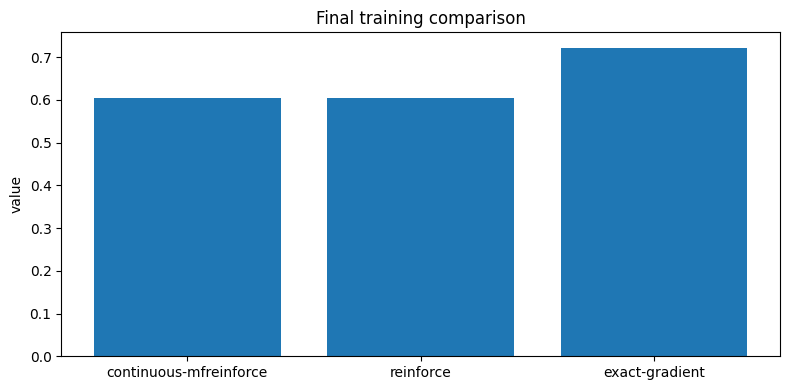

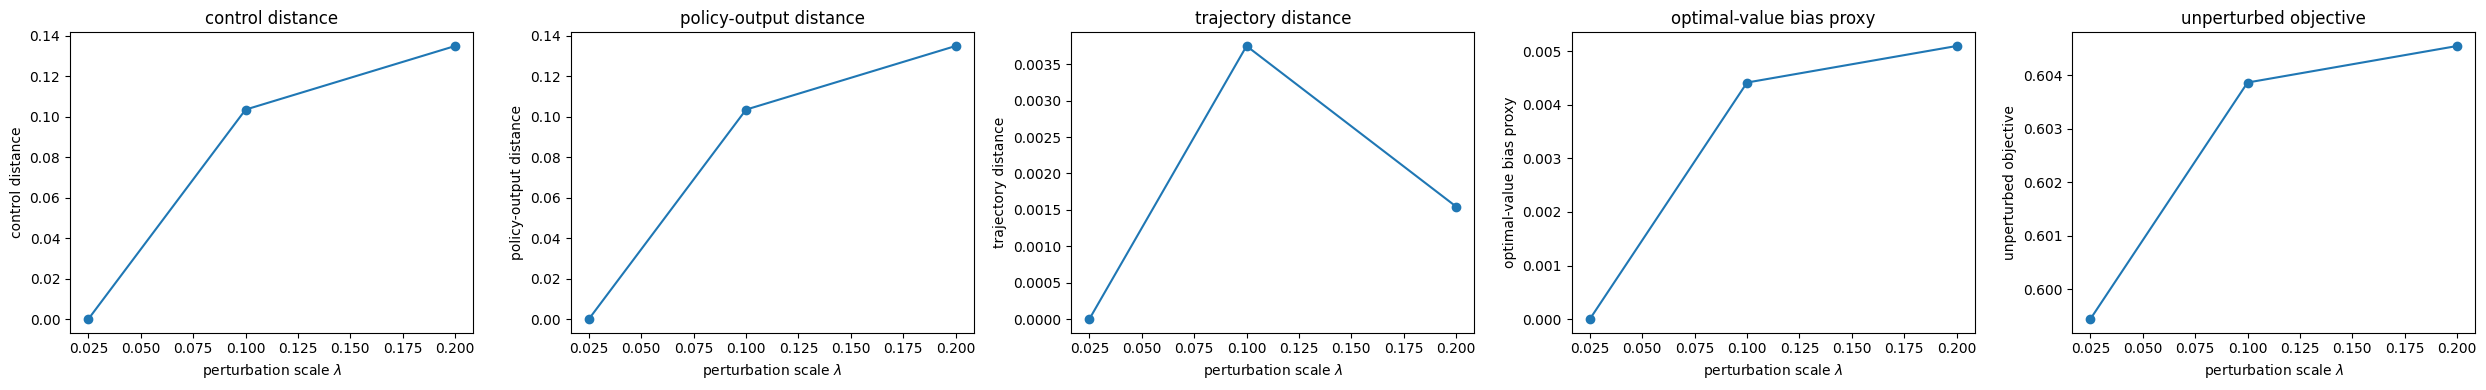

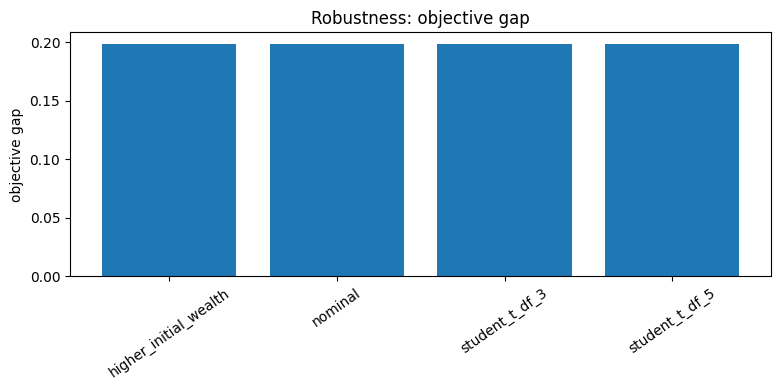

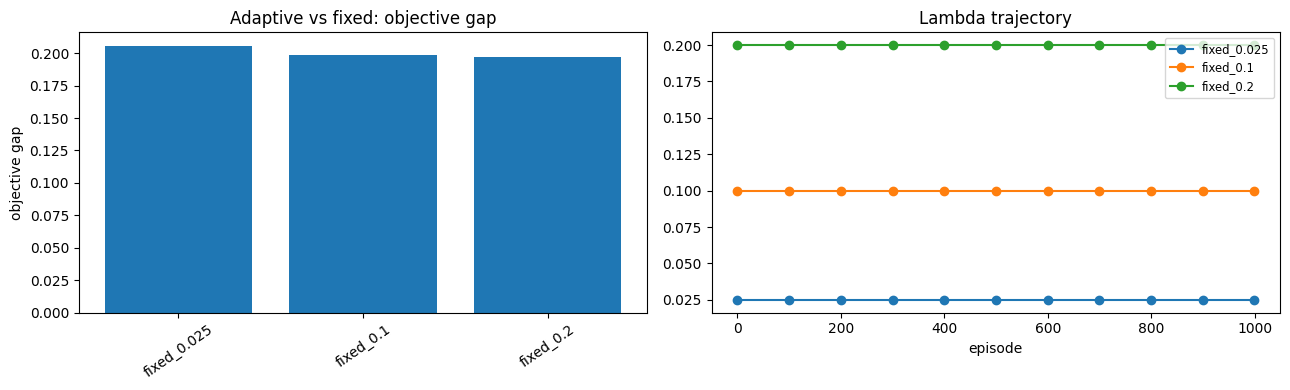

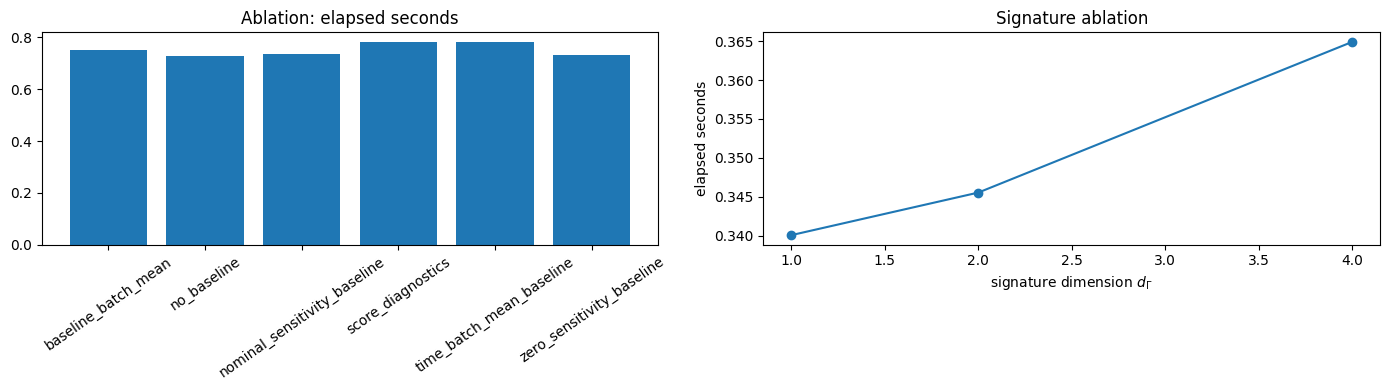

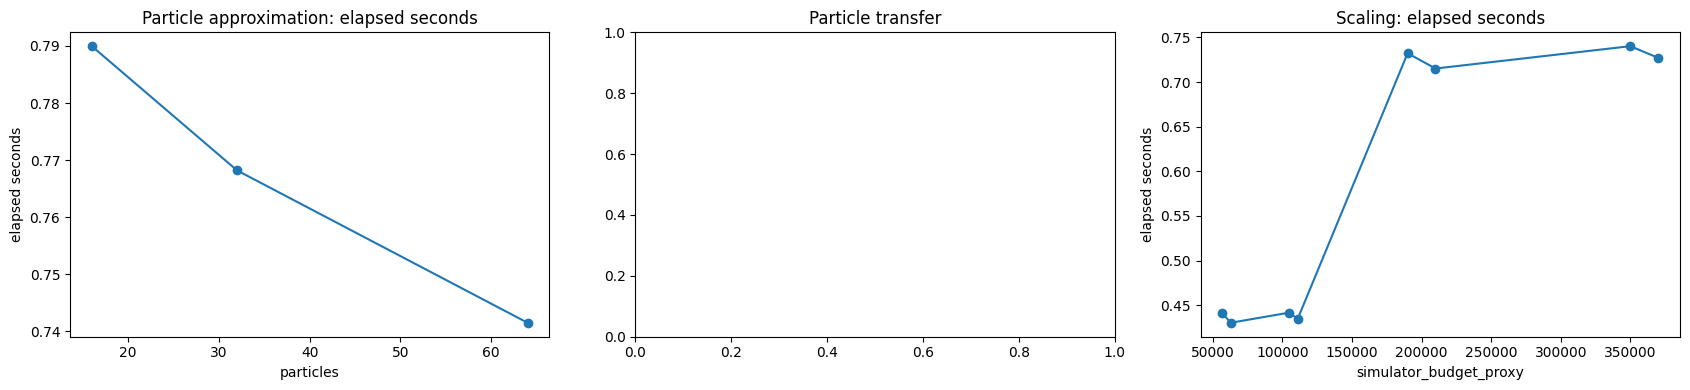

In [5]:
nh.plot_budget_and_horizon(studies)
nh.plot_budget_pareto(studies, grid_metrics)
nh.plot_lambda_training_comparison(studies)
nh.plot_optimization_history(optimization_history)
nh.plot_optimization_summary(studies)
nh.plot_extended_study_summaries(studies, grid_metrics)


## Figure Coverage Audit

These tables map the broader requested figure list to saved artifacts. They are useful for checking completeness; they are not meant to be the headline story of the benchmark.


In [6]:
nh.figure_checklist(ENV_NAME)


,figure_family,command_or_study,files,notebook_section
0,perturbation_geometry,diagnose-perturbation,"diagnostics.csv, perturbation_samples.csv",universal diagnostics
1,functional_law,diagnose-functional-law,"diagnostics.csv, signature_samples.csv, functi...",universal diagnostics
2,score_validation,score-validation,"diagnostics.csv, score_coordinates.csv, score_...",universal diagnostics
3,gradient_validation,diagnose-gradient,"diagnostics.csv, gradient_samples.csv, gradien...",universal diagnostics
4,sensitivity_validation,diagnose-sensitivity,"diagnostics.csv, sensitivity_samples.csv",universal diagnostics
5,horizon_scaling,horizon-scaling,"grid_metrics.csv, diagnostics.csv",study sweeps
6,budget_allocation,budget-allocation,"grid_metrics.csv, diagnostics.csv",study sweeps
7,particle_approximation,particle-approximation,"grid_metrics.csv, diagnostics.csv",study sweeps
8,particle_transfer,particle-transfer,"diagnostics.csv, optimization_history.csv",study sweeps
9,ablation,ablation,"grid_metrics.csv, diagnostics.csv",study sweeps


In [7]:
nh.figure_coverage_matrix(ENV_NAME)


,figure_or_result,status,notebook_helper,artifact
0,"perturbation mean, bands, and empirical slopes",ready,"plot_perturbation_geometry, plot_perturbation_...",diagnostics/*_perturbation/diagnostics.csv
1,finite-state d_TV perturbation calibration and...,ready,"perturbation_tv_comparison_table, plot_perturb...","diagnostics/*_perturbation/diagnostics.csv, di..."
2,functional-law signature summaries,ready,"plot_functional_law, plot_functional_signature...",diagnostics/*_functional_law/diagnostics.csv
3,"functional-law histograms, pair plots, Q-Q plots",ready,plot_functional_sample_diagnostics,diagnostics/*_functional_law/signature_samples...
4,"score mean, variance, lambda^2 variance, coord...",ready,"plot_score_validation, plot_score_coordinate_d...",diagnostics/*_score/*.csv
5,"gradient bias, variance, MSE, cosine, norm, de...",ready,"plot_gradient_validation, plot_gradient_error_...",diagnostics/*_gradient/diagnostics.csv
6,coordinatewise gradient scatter and CI coverage,ready,plot_gradient_coordinate_diagnostics,diagnostics/*_gradient/gradient_coordinates.cs...
7,sensitivity error vs time/eta and heatmap,ready,"plot_sensitivity_validation, plot_sensitivity_...",diagnostics/*_sensitivity/diagnostics.csv
8,budget allocation heatmap and runtime Pareto,ready,"plot_budget_and_horizon, plot_budget_pareto",studies/budget_allocation/*.csv
9,horizon scaling,ready,plot_budget_and_horizon,studies/horizon_scaling/*.csv


## Raw Tables For Custom Figures

The first few rows below are the main saved tables used by the plots above. Use these as the entry point for custom figures without rerunning training.


In [8]:
sample_algorithm = next(iter(application))
sample_diag_algorithm = next(iter(diagnostics))
(
    application[sample_algorithm]["time_metrics"].head(),
    diagnostics[sample_diag_algorithm].get("gradient", pd.DataFrame()).head(),
    studies.get("budget", pd.DataFrame()).head(),
)


(         env  time      mean  variance  optimal_mean  optimal_variance  \
 0  portfolio     0  1.000000  0.040000      1.000000          0.040000   
 1  portfolio     1  1.000863  0.040044      1.005393          0.038115   
 2  portfolio     2  1.001788  0.039959      1.010468          0.036288   
 3  portfolio     3  1.001605  0.039954      1.015245          0.034521   
 4  portfolio     4  1.002264  0.039938      1.019741          0.032817   
 
    mean_error  variance_error  
 0    0.000000        0.000000  
 1    0.004530        0.001929  
 2    0.008680        0.003671  
 3    0.013640        0.005433  
 4    0.017477        0.007121  ,
    lambda  replications  estimate_norm  variance_trace  \
 0   0.025             8      74.078298    35147.453616   
 1   0.100             8      45.547137    14910.808376   
 2   0.200             8      32.852115     8357.180130   
 
    covariance_largest_eigenvalue  oracle_norm  bias_norm  relative_bias  \
 0                   32003.724469  